### 실습 1. 전처리 데이터 불러오기

해야 할 일

먼저 Chapter 01에서 만든 CSV 파일을 pandas로 불러옵니다.

처음부터 단어를 분리하지 말고 데이터가 정상적으로 연결되는지 먼저 확인합니다.

In [78]:
import pandas as pd

# 같은 폴더의 CSV 파일 불러오기
df_books = pd.read_csv("book_bestseller_clean.csv", encoding="utf-8-sig")

# 데이터 기본 내용 확인
print("행과 컬럼 개수:", df_books.shape)
print("컬럼 이름:", df_books.columns)
print("'상품명' 컬럼이 있나요?", "상품명" in df_books.columns)

# 앞의 5행 확인
display(df_books.head())

행과 컬럼 개수: (199, 8)
컬럼 이름: Index(['순위', '판매상품ID', '상품명', '판매가', '저자', '출판사', '발행일', '분야'], dtype='str')
'상품명' 컬럼이 있나요? True


,순위,판매상품ID,상품명,판매가,저자,출판사,발행일,분야
0,1,S000000610612,소년이 온다,13500,한강,창비,2014-05-19,소설
1,2,S000001632467,모순,11700,양귀자,쓰다,2013-04-01,소설
2,3,S000216262757,결국 국민이 합니다,19800,이재명,오마이북,2025-04-15,정치/사회
3,4,S000216111714,혼모노,16200,성해나,창비,2025-03-28,소설
4,5,S000200550189,급류,12600,정대건,민음사,2022-12-22,소설


### 실행 결과

전처리한 CSV 파일을 `df_books`로 불러왔습니다.

데이터는 **199행, 8개 컬럼**이며, `상품명` 컬럼이 있는 것도 확인했습니다.

앞의 5행에서 책의 순위, 상품명, 판매가 등의 값이 표시됩니다.

### 실습 2. 분석할 도서 제목 확인하기

단어 분석을 시작하기 전에 상품명 데이터가 어떤 형태인지 직접 확인합니다.

In [79]:
# 상품명 앞의 20개 확인
print("상품명 앞의 20개:")
display(df_books["상품명"].head(20))

# 상품명 결측치 개수 확인
print("상품명 결측치 개수:", df_books["상품명"].isna().sum())

# 빈 값을 채우고, 문자열로 바꾼 뒤 앞뒤 공백 제거
titles = df_books["상품명"].fillna("").astype(str).str.strip()

print("정리한 제목 앞의 5개:")
display(titles.head())

# 빈 제목을 제외하고 사용할 제목 개수 확인
titles = titles[titles != ""]
print("사용할 제목 개수:", len(titles))

상품명 앞의 20개:


0                        소년이 온다
1                            모순
2                    결국 국민이 합니다
3                           혼모노
4                            급류
5                      초역 부처의 말
6                 청춘의 독서(특별증보판)
7                  어른의 행복은 조용하다
8                         채식주의자
9      단 한 번의 삶(강물에디션 활판인쇄 한정판)
10                     작별하지 않는다
11                          스토너
12           해커스 토익 기출 VOCA(보카)
13    다크 심리학(20만 부 한정판 스페셜 에디션)
14                 트렌드 코리아 2026
15                         위버멘쉬
16                          가공범
17                       듀얼 브레인
18         행동하지 않으면 인생은 바뀌지 않는다
19                  절창(화이트 에디션)
Name: 상품명, dtype: str

상품명 결측치 개수: 0
정리한 제목 앞의 5개:


0        소년이 온다
1            모순
2    결국 국민이 합니다
3           혼모노
4            급류
Name: 상품명, dtype: str

사용할 제목 개수: 199


### 상품명 확인 결과

상품명 앞의 20개를 확인했습니다.

일부 제목에는 괄호로 표시된 판본 정보와 영어·숫자가 포함되어 있어, 단어를 나누기 전에 제목의 형태를 살펴볼 필요가 있습니다.

### 실습 3. Dictionary로 단어 빈도 세기

먼저 예시 단어를 하나씩 읽으며 각 단어가 몇 번 나오는지 세어 봅니다.

단어별 횟수는 Dictionary에 저장하고, 같은 단어가 다시 나오면 1을 더합니다.

이 방법을 익힌 뒤 실제 도서 제목에도 적용합니다.

In [80]:
# 빈도를 셀 예시 단어
sample_words = ["데이터", "분석", "파이썬", "데이터", "AI", "분석", "데이터"]

# 방법 1: 단어가 이미 있는지 확인하며 세기 ( if-else 방식 집계 결과 )
word_counts = {}

for word in sample_words:
    if word in word_counts:
        word_counts[word] += 1
    else:
        word_counts[word] = 1

print("기본 방법:", word_counts)

# 방법 2: get()을 이용해 더 간단하게 세기 ( get()함수 방식 집계 결과 )
word_counts = {}

for word in sample_words:
    word_counts[word] = word_counts.get(word, 0) + 1

print("get() 방법:", word_counts)

기본 방법: {'데이터': 3, '분석': 2, '파이썬': 1, 'AI': 1}
get() 방법: {'데이터': 3, '분석': 2, '파이썬': 1, 'AI': 1}


### 실행 결과

`데이터`는 3번, `분석`은 2번, `파이썬`과 `AI`는 각각 1번 나왔습니다.

기본 방법과 `get()`을 사용한 방법의 결과가 같아, 단어가 나올 때마다 횟수를 1씩 더하는 원리를 확인했습니다.

### 실습 4. Counter로 단어 빈도 세기

앞에서는 Dictionary로 단어가 나올 때마다 횟수를 직접 더했습니다.

`Counter`를 사용하면 같은 작업을 더 간단하게 할 수 있습니다.

`most_common()`으로 많이 나온 단어부터 확인하고, `most_common(3)`으로 상위 3개만 볼 수 있습니다.

In [81]:
from collections import Counter

# 빈도를 셀 예시 단어
sample_words = ["데이터", "분석", "파이썬", "데이터", "AI", "분석", "데이터"]

# 단어별 등장 횟수 세기
sample_counter = Counter(sample_words)
print("단어별 빈도:", sample_counter)

# 많이 나온 단어부터 확인
print("빈도순:", sample_counter.most_common())

# 상위 3개만 확인
print("상위 3개:", sample_counter.most_common(3))

단어별 빈도: Counter({'데이터': 3, '분석': 2, '파이썬': 1, 'AI': 1})
빈도순: [('데이터', 3), ('분석', 2), ('파이썬', 1), ('AI', 1)]
상위 3개: [('데이터', 3), ('분석', 2), ('파이썬', 1)]


### 실행 결과

`Counter`로 단어별 등장 횟수를 확인했습니다.

`데이터`가 3번으로 가장 많이 나왔고, `분석`은 2번, `파이썬`과 `AI`는 각각 1번 나왔습니다.

`most_common(3)`으로 빈도 상위 3개도 확인했습니다.

### 실습 5. pandas로 단어 빈도 세기

예시 단어를 pandas `Series`로 만든 뒤 `value_counts()`로 단어별 등장 횟수를 확인합니다.

Dictionary와 Counter로 구한 결과와 비교해 봅니다.

In [82]:
import pandas as pd

sample_words = ["데이터", "분석", "파이썬", "데이터", "AI", "분석", "데이터"]

sample_series = pd.Series(sample_words)
print(sample_series.value_counts())

데이터    3
분석     2
파이썬    1
AI     1
Name: count, dtype: int64


### 실행 결과

`value_counts()`로 확인한 결과, `데이터`는 3번, `분석`은 2번, `파이썬`과 `AI`는 각각 1번 나왔습니다.

앞서 Dictionary와 Counter로 센 결과와 같습니다.

### + 질문: Counter와 value_counts() 중 어느 쪽이 더 빠른가요?

몇 건부터 어느 쪽이 더 빠르다는 고정 기준은 없습니다. 데이터의 형태와 처리 방식에 따라 달라집니다.

- 단어가 **리스트**에 있다면 `Counter`를 쓰기 편합니다.
- 데이터가 이미 pandas **Series**에 있다면 `value_counts()`를 쓰기 편합니다.

현재 실습의 도서 199건에서는 속도 차이보다 데이터 형태에 맞는 방법을 선택하는 것이 좋습니다.

### 실습 6. 제목을 간단하게 단어로 나누기

정규표현식으로 제목에서 한글·영어·숫자로 된 부분을 추출합니다.

먼저 예시 제목으로 결과를 확인하고, 단순하게 나눈 단어가 실제 의미 단위와 다를 수 있다는 점도 살펴봅니다.

In [83]:
import re  # 문자열에서 원하는 부분을 찾는 도구

# 제목을 받아 한글·영어·숫자로 된 부분을 리스트로 반환
def simple_tokenize(text):
    # 영어는 소문자로 바꾸고, 쉼표·느낌표 같은 기호는 제외
    return re.findall(r"[가-힣A-Za-z0-9]+", str(text).lower())

# 함수가 잘 작동하는지 예시 제목으로 확인
sample_title = "AI 시대의 데이터 분석, Python으로 시작하기!"

print(sample_title)
print(simple_tokenize(sample_title))

AI 시대의 데이터 분석, Python으로 시작하기!
['ai', '시대의', '데이터', '분석', 'python으로', '시작하기']


### 실행 결과

예시 제목이 `['ai', '시대의', '데이터', '분석', 'python으로', '시작하기']`로 나뉘었습니다.

영어는 소문자로 바뀌었지만, `시대의`와 `python으로`처럼 조사가 붙은 부분은 그대로 남았습니다.

간단한 정규표현식만으로는 의미에 맞게 단어를 정확히 나누기 어렵다는 점을 확인했습니다.

### 실습 7. 모든 제목에서 단어 모으기

앞에서 만든 `titles`의 제목을 하나씩 나누어 `simple_words`에 모읍니다.

`extend()`는 나눈 단어들을 리스트에 하나씩 이어 붙입니다.

`append()`와 결과가 어떻게 다른지도 확인합니다.

In [84]:
# 모든 제목에서 추출한 단어를 하나의 리스트에 모으기
simple_words = []

for title in titles:
    words = simple_tokenize(title)
    simple_words.extend(words)

print("전체 단어 수:", len(simple_words))
print("앞의 50개 단어:", simple_words[:50])

# append()와 extend()의 차이 확인
example = []
example.append(["데이터", "분석"])
print("append 결과:", example)

example = []
example.extend(["데이터", "분석"])
print("extend 결과:", example)

전체 단어 수: 760
앞의 50개 단어: ['소년이', '온다', '모순', '결국', '국민이', '합니다', '혼모노', '급류', '초역', '부처의', '말', '청춘의', '독서', '특별증보판', '어른의', '행복은', '조용하다', '채식주의자', '단', '한', '번의', '삶', '강물에디션', '활판인쇄', '한정판', '작별하지', '않는다', '스토너', '해커스', '토익', '기출', 'voca', '보카', '다크', '심리학', '20만', '부', '한정판', '스페셜', '에디션', '트렌드', '코리아', '2026', '위버멘쉬', '가공범', '듀얼', '브레인', '행동하지', '않으면', '인생은']
append 결과: [['데이터', '분석']]
extend 결과: ['데이터', '분석']


### 실행 결과

모든 도서 제목에서 추출한 단어는 **총 760개**입니다.

앞의 50개를 확인해 제목이 단어처럼 나뉘어 리스트에 모인 것을 볼 수 있습니다.

같은 단어가 여러 번 나오면 각각 포함되므로, 760개는 서로 다른 단어의 개수가 아닙니다.

`append()`는 리스트 전체를 한 항목으로 넣어 `[['데이터', '분석']]`가 되었고, `extend()`는 단어를 하나씩 넣어 `['데이터', '분석']`가 되었습니다.

### 실습 8. 자주 나오는 단어 확인하기

앞에서 모은 단어의 등장 횟수를 `Counter`로 세고, 상위 30개를 표로 확인합니다.

단어를 바로 시각화하기 전에 한 글자 단어, 숫자, 판본 표시처럼 분석에 불필요할 수 있는 표현이 있는지 살펴봅니다.


[ 전처리 방향 결정을 위한 5가지 질문 ]

의미 없는 한 글자 단어가 많은가?

조사나 어미가 붙은 단어가 있는가?

같은 의미인데 다른 형태로 분리된 단어가 있는가?

숫자가 지나치게 많이 등장하는가?

'개정판', '세트'처럼 분석 목적과 관계가 적은 표현이 많은가?

In [85]:
from collections import Counter
import pandas as pd

# 단어별 등장 횟수 세기
simple_counter = Counter(simple_words)

# 가장 많이 나온 단어 30개를 표로 만들기
simple_top30 = pd.DataFrame(
    simple_counter.most_common(30),
    columns=["단어", "빈도"]
)

display(simple_top30)

,단어,빈도
0,에디션,12
1,부,9
2,기념,8
3,리커버,8
4,한,7
5,해커스,7
6,위한,7
7,말,6
8,토익,6
9,스페셜,5


### 단어 빈도 확인 결과

가장 많이 나온 단어는 `에디션`(12회)이었고, 다음은 `부`(9회), `기념`과 `리커버`(각 8회)였습니다.

상위 단어에 판본 관련 표현과 한 글자 단어, 숫자가 포함되어 있어 다음 분석 전에 제외할 단어를 살펴봐야겠습니다.

### 실습 9. pandas로 단어 빈도 확인하기

`simple_words`를 pandas Series로 바꾸고, `value_counts()`로 자주 나온 단어 30개를 확인합니다.

앞에서 만든 Counter 결과와 상위 단어의 빈도를 비교합니다.

In [86]:
import pandas as pd

# 단어 리스트를 pandas Series로 변환
simple_word_series = pd.Series(simple_words)

# pandas로 빈도 상위 30개 확인
print("pandas 상위 30개:")
print(simple_word_series.value_counts().head(30))

# Counter 결과와 상위 10개 비교
print("\nCounter 상위 10개:")
print(simple_counter.most_common(10))

print("\npandas 상위 10개:")
print(simple_word_series.value_counts().head(10))

pandas 상위 30개:
에디션     12
부        9
기념       8
리커버      8
한        7
해커스      7
위한       7
말        6
토익       6
스페셜      5
나는       5
내가       5
대하여      4
싶은       4
lc       4
rc       4
1        4
단        3
한정판      3
않는다      3
voca     3
트렌드      3
2026     3
30만      3
돈의       3
때        3
2025     3
일본어      3
없는       3
필사       3
Name: count, dtype: int64

Counter 상위 10개:
[('에디션', 12), ('부', 9), ('기념', 8), ('리커버', 8), ('한', 7), ('해커스', 7), ('위한', 7), ('말', 6), ('토익', 6), ('스페셜', 5)]

pandas 상위 10개:
에디션    12
부       9
기념      8
리커버     8
한       7
해커스     7
위한      7
말       6
토익      6
스페셜     5
Name: count, dtype: int64


### 실행 결과

pandas와 Counter의 상위 10개 단어 및 빈도가 같았습니다.

가장 많이 나온 단어는 `에디션`(12회)이고, 다음은 `부`(9회), `기념`과 `리커버`(각 8회)입니다.

두 방법으로 단어 빈도가 동일하게 집계된 것을 확인했습니다.

### 실습 10. 형태소 분석이 필요한 이유

한국어는 같은 단어에도 조사가 붙어 `데이터가`, `데이터를`처럼 여러 형태로 나타납니다.
단순히 글자를 나누면 이들을 서로 다른 단어로 셀 수 있습니다.
도서 제목에서 주요 주제를 살펴보기 위해 다음 단계에서는 명사 중심으로 단어를 추출합니다.

### 실습 11. Kiwi 형태소 분석기 설치하기

한글 형태소 분석 도구는 여러 가지가 있습니다.

이번 실습에서는 Windows 환경에서도 비교적 설치가 간단한 kiwipiepy를 사용합니다.

터미널에서 현재 사용하는 Python 가상환경이 활성화되어 있는지 확인한 뒤 설치합니다.

### 실습 12. Kiwi로 품사 확인하기

짧은 제목을 Kiwi로 분석해 각 단어의 형태와 품사 태그를 확인합니다.

특히 일반 명사(`NNG`), 고유 명사(`NNP`), 영문 표현(`SL`)이 어떻게 표시되는지 살펴봅니다.

In [87]:
from kiwipiepy import Kiwi

# 형태소 분석기 만들기
kiwi = Kiwi()

# 예시 제목 분석하기
sample_title = "AI 시대의 데이터 분석을 위한 파이썬"
tokens = kiwi.tokenize(sample_title)

# 분석된 형태와 품사 태그 확인하기
for token in tokens:
    print(token.form, token.tag)

KeyboardInterrupt: 

### 실행 결과

Kiwi가 예시 제목을 형태소와 품사로 나누었습니다.

`AI`는 영문 표현(`SL`), `시대`·`데이터`·`분석`은 일반 명사(`NNG`), `파이썬`은 고유 명사(`NNP`)로 표시되었습니다.

`의`, `을` 같은 조사도 별도로 분리된 것을 확인했습니다.

### 실습 13. 명사 중심으로 단어 추출하기

Kiwi가 나눈 형태소 중 일반 명사(`NNG`), 고유 명사(`NNP`), 영문 표현(`SL`)만 선택합니다.

영문은 소문자로 통일해 `AI`와 `ai`가 같은 단어로 집계되도록 합니다.

In [ ]:
from kiwipiepy import Kiwi

kiwi = Kiwi()

# 추출할 품사: 일반 명사, 고유 명사, 영문 표현
TARGET_TAGS = {"NNG", "NNP", "SL"}

def extract_words(text):
    result = []

    # 문장을 분석하고 원하는 품사만 선택
    for token in kiwi.tokenize(str(text)):
        if token.tag in TARGET_TAGS:
            word = token.form.strip().lower()
            result.append(word)

    return result

# 예시 문장으로 확인
print(extract_words("AI 시대의 데이터 분석을 위한 파이썬"))

['ai', '시대', '데이터', '분석', '파이썬']


In [ ]:
song = "동해물과 백두산이 마르고 닳도록 하느님이 보우하사 우리나라 만세"

def extract_words(song):
    result = []

    # 문장을 분석하고 원하는 품사만 선택
    for token in kiwi.tokenize(str(song)):
        if token.tag in TARGET_TAGS:
            word = token.form.strip().lower()
            result.append(word)

    return result

print(extract_words(song))

['동해', '물', '백두산', '하느님', '보우', '나라']


### 실행 결과

예시 문장에서 `ai`, `시대`, `데이터`, `분석`, `파이썬`을 추출했습니다.

조사와 동사 표현은 제외되었고, `AI`는 소문자 `ai`로 바뀌었습니다.

### 실습 14. 한 글자 단어 제외하기

이번 분석에서는 결과를 보기 쉽게 하기 위해 2글자 이상의 일반 명사, 고유 명사, 영문 표현만 사용합니다.

한 글자 단어가 중요하다면 이 기준은 바꿀 수 있습니다.

In [ ]:
# 2글자 이상의 단어만 사용
MIN_LENGTH = 2

def extract_words(text):
    result = []

    for token in kiwi.tokenize(str(text)):
        if token.tag in TARGET_TAGS:
            word = token.form.strip().lower()

            if len(word) >= MIN_LENGTH:
                result.append(word)

    return result

# 실제 도서 제목 앞의 5개에 적용해 결과 확인
for title in df_books["상품명"].head():
    print(title, "→", extract_words(title))

소년이 온다 → ['소년']
모순 → ['모순']
결국 국민이 합니다 → ['국민']
혼모노 → ['혼모']
급류 → ['급류']


### 실행 결과

실제 도서 제목 앞의 5개에 2글자 이상 필터를 적용했습니다.

`소년이 온다`에서는 `소년`, `결국 국민이 합니다`에서는 `국민`이 추출되었습니다.

조사와 동사 표현은 제외되었습니다.

`혼모노`가 `혼모`로 추출된 것처럼 형태소 분석 결과가 제목의 의미와 다를 수 있어, 실제 결과를 확인하며 사용해야 합니다.

### 실습 15. 모든 도서 제목에서 명사 추출하기

실제 도서 제목 전체에 `extract_words()`를 적용해 단어를 모읍니다.

자주 나온 단어 30개를 확인한 뒤, 앞에서 사용한 단순 토큰화 결과와 비교합니다.

의미 있는 단어가 잘 남았는지도 살펴봅니다.

In [ ]:
from collections import Counter
import pandas as pd

# 모든 도서 제목에서 단어 추출
filtered_words = []

for title in titles:
    words = extract_words(title)
    filtered_words.extend(words)

print("추출된 전체 단어 수:", len(filtered_words))
print("앞의 50개 단어:", filtered_words[:50])

# 단어별 빈도 계산
noun_counter = Counter(filtered_words)

# 빈도 상위 30개를 표로 만들기
noun_top30 = pd.DataFrame(
    noun_counter.most_common(30),
    columns=["단어", "빈도"]
)

print("\n형태소 분석 후 상위 30개:")
display(noun_top30)

# 단순 토큰화 결과와 비교
print("단순 토큰화 상위 10개:")
display(simple_top30.head(10))

print("형태소 분석 후 상위 10개:")
display(noun_top30.head(10))

추출된 전체 단어 수: 463
앞의 50개 단어: ['소년', '모순', '국민', '혼모', '급류', '초역', '부처', '청춘', '독서', '특별', '증보판', '어른', '행복', '채식주의자', '강물에디션', '활판', '인쇄', '한정판', '작별', '스토너', '해커스', '토익', '기출', 'voca', '보카', '다크', '심리학', '한정판', '스페셜', '에디션', '트렌드', '코리아', '위버멘쉬', '가공범', '듀얼', '브레인', '행동', '인생', '절창', '화이트', '에디션', '쇼펜하우어', '인생', '수업', '기념', '개정', '증보판', '남매', '행복', '정도']

형태소 분석 후 상위 30개:


,단어,빈도
0,에디션,14
1,기념,10
2,토익,8
3,해커스,7
4,리커버,7
5,스페셜,5
6,필사,5
7,인생,4
8,수업,4
9,시대,4


단순 토큰화 상위 10개:


,단어,빈도
0,에디션,12
1,부,9
2,기념,8
3,리커버,8
4,한,7
5,해커스,7
6,위한,7
7,말,6
8,토익,6
9,스페셜,5


형태소 분석 후 상위 10개:


,단어,빈도
0,에디션,14
1,기념,10
2,토익,8
3,해커스,7
4,리커버,7
5,스페셜,5
6,필사,5
7,인생,4
8,수업,4
9,시대,4


### 실행 결과

전체 도서 제목에서 **463개 단어**를 추출했습니다. 가장 자주 나온 단어는 `에디션`(14회), `기념`(10회), `토익`(8회)입니다.

`인생`, `수업`, `시대`처럼 주제를 나타내는 단어도 보이지만, `에디션`, `리커버`, `한정판`처럼 판본을 설명하는 단어도 남아 있습니다.

`혼모노`가 `혼모`로 추출된 사례처럼 분석 결과를 확인하며 해석해야 합니다.

### 실습 16. 불용어 이해하기

앞서 확인한 빈도 결과에는 `에디션`, `리커버`, `한정판`처럼 판본을 설명하는 단어도 있었습니다. 이런 단어가 도서의 주제를 파악하는 데 필요한지 원본 제목에서 먼저 확인합니다.

분석 목적과 관계가 적다고 판단한 단어만 불용어로 추가하고, 제거한 뒤의 결과를 다시 살펴봅니다.

### 실습 17. 불용어 목록 만들기

이번에는 판본을 설명하는 단어 5개를 불용어로 정했습니다. `extract_words()`는 품사, 글자 수, 불용어를 차례로 확인해 조건에 맞는 단어만 반환합니다.

In [ ]:
from collections import Counter

# 사용할 품사와 최소 글자 수
TARGET_TAGS = {"NNG", "NNP", "SL"}
MIN_LENGTH = 2

# 분석에서 제외할 단어
STOPWORDS = {"세트", "개정판", "에디션", "리커버", "한정판"}

def extract_words(text):
    result = []

    for token in kiwi.tokenize(str(text)):
        # 일반 명사, 고유 명사, 영문 표현만 사용
        if token.tag not in TARGET_TAGS:
            continue

        word = token.form.strip().lower()

        # 한 글자 단어와 불용어는 제외
        if len(word) < MIN_LENGTH or word in STOPWORDS:
            continue

        result.append(word)

    return result

# 실제 도서 제목 전체에 적용
filtered_words = []

for title in df_books["상품명"]:
    filtered_words.extend(extract_words(title))

print("추출된 전체 단어 수:", len(filtered_words))
print("빈도 상위 10개:", Counter(filtered_words).most_common(10))

추출된 전체 단어 수: 438
빈도 상위 10개: [('기념', 10), ('토익', 8), ('해커스', 7), ('스페셜', 5), ('필사', 5), ('인생', 4), ('수업', 4), ('시대', 4), ('lc', 4), ('rc', 4)]


### 실행 결과

불용어를 적용한 뒤 추출된 단어는 **438개**로, 적용 전 463개보다 25개 줄었습니다. 가장 자주 나온 단어는 `기념`(10회), `토익`(8회), `해커스`(7회)입니다.

지정한 불용어는 제외되었지만, `기념`과 `스페셜`처럼 판본을 설명할 수 있는 단어가 여전히 보입니다. 이 단어들도 제외할지는 원본 제목을 보고 결정할 수 있습니다.

### 실습 18. 최종 단어 빈도 저장하기

앞에서 정한 품사·글자 수·불용어 기준을 실제 도서 제목 전체에 적용합니다. 단어 빈도 상위 30개를 표로 확인하고 CSV 파일로 저장합니다.

In [ ]:
from collections import Counter
from pathlib import Path
import pandas as pd

# 실제 도서 제목 전체에서 단어 추출
final_words = []

for title in df_books["상품명"]:
    final_words.extend(extract_words(title))

print("최종 단어 수:", len(final_words))
print("앞의 50개 단어:", final_words[:50])

# 단어별 빈도 계산
final_counter = Counter(final_words)

# 빈도 상위 30개를 표로 만들기
top30 = pd.DataFrame(
    final_counter.most_common(30),
    columns=["단어", "빈도"]
)

display(top30)

# CSV 파일로 저장하고 생성 여부 확인
file_name = "chapter02_top30_words.csv"
top30.to_csv(file_name, index=False, encoding="utf-8-sig")

print("파일 생성 확인:", Path(file_name).exists())

최종 단어 수: 438
앞의 50개 단어: ['소년', '모순', '국민', '혼모', '급류', '초역', '부처', '청춘', '독서', '특별', '증보판', '어른', '행복', '채식주의자', '강물에디션', '활판', '인쇄', '작별', '스토너', '해커스', '토익', '기출', 'voca', '보카', '다크', '심리학', '스페셜', '트렌드', '코리아', '위버멘쉬', '가공범', '듀얼', '브레인', '행동', '인생', '절창', '화이트', '쇼펜하우어', '인생', '수업', '기념', '개정', '증보판', '남매', '행복', '정도', '기념', '교보문고', '단독', '안녕']


,단어,빈도
0,기념,10
1,토익,8
2,해커스,7
3,스페셜,5
4,필사,5
5,인생,4
6,수업,4
7,시대,4
8,lc,4
9,rc,4


파일 생성 확인: True


### 실행 결과

최종 기준으로 추출한 단어는 **438개**입니다. 빈도 상위 30개를 표로 확인했으며, 가장 많이 나온 단어는 `기념`(10회), `토익`(8회), `해커스`(7회)입니다.

`스페셜`, `증보판`처럼 판본과 관련된 표현도 남아 있습니다. 이 단어들을 추가로 제외할지는 분석 목적에 따라 결정할 수 있습니다.

### 실습 19. 상위 단어 막대그래프

앞에서 만든 `top30`의 단어 빈도를 막대그래프로 확인합니다. 한글이 깨지지 않는지, 가장 긴 막대의 단어와 빈도가 표의 결과와 같은지 살펴봅니다.

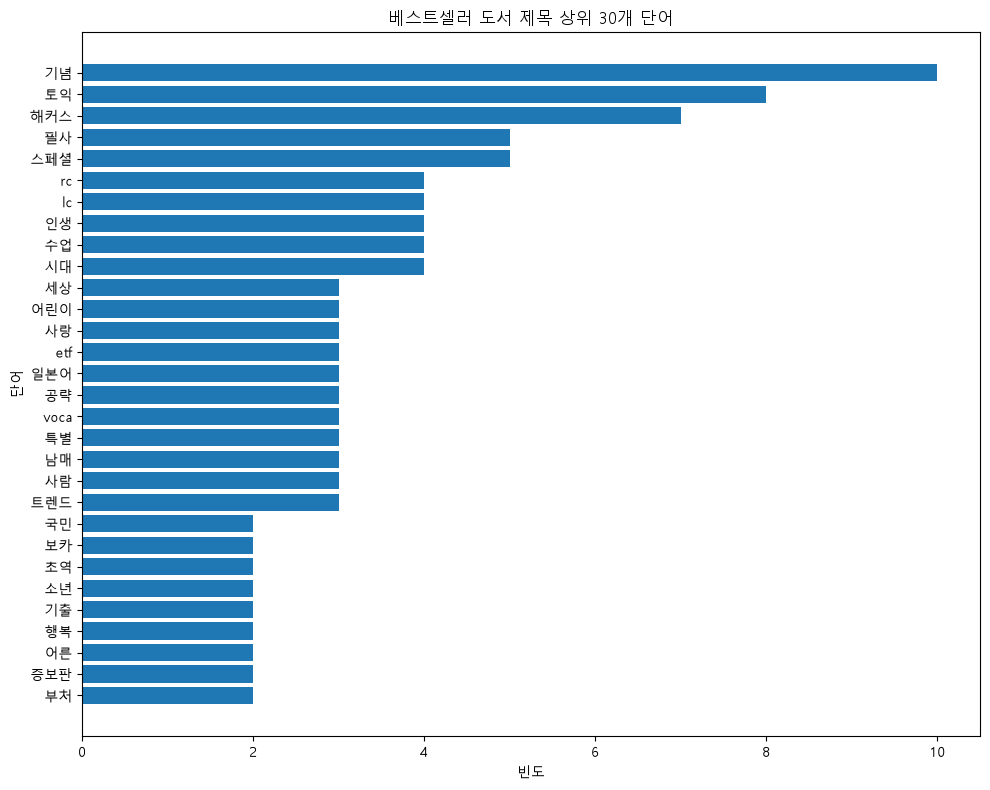

In [ ]:
import matplotlib.pyplot as plt

# Windows에서 한글이 표시되도록 설정
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

# 빈도가 높은 단어가 위쪽에 오도록 정렬
plot_data = top30.sort_values("빈도", ascending=True)

plt.figure(figsize=(10, 8))
plt.barh(plot_data["단어"], plot_data["빈도"])

plt.xlabel("빈도")
plt.ylabel("단어")
plt.title("베스트셀러 도서 제목 상위 30개 단어")

plt.tight_layout()
plt.show()

### 실행 결과

한글이 깨지지 않고 상위 30개 단어가 막대그래프로 표시되었습니다.

`기념`(10회)의 막대가 가장 길고, `토익`(8회), `해커스`(7회)가 뒤를 이어 앞서 확인한 빈도표와 같습니다.

막대그래프에서 단어별 빈도 차이를 쉽게 비교할 수 있습니다.

### 실습 20. Word Cloud 설치하기

Word Cloud를 만들기 전에 현재 가상환경에 `wordcloud`가 설치되어 있는지 확인합니다. 설치 후 Notebook에서 `WordCloud`를 불러와 정상적으로 사용할 수 있는지 확인합니다.

In [ ]:
from wordcloud import WordCloud

print("WordCloud 불러오기 성공")

WordCloud 불러오기 성공


### 실습 21. Word Cloud용 한글 폰트 확인하기

Word Cloud에 한글을 표시하기 위해 맑은 고딕 폰트 파일이 있는지 확인합니다. 결과가 `True`이면 이 경로를 사용할 수 있습니다.

In [ ]:
from pathlib import Path

# 맑은 고딕 폰트 파일 경로
FONT_PATH = Path("C:/Windows/Fonts/malgun.ttf")

# 파일이 실제로 있는지 확인
print("폰트 파일 존재 여부:", FONT_PATH.exists())

폰트 파일 존재 여부: True


### 실습 22. Word Cloud 만들기

앞에서 계산한 `final_counter`의 단어 빈도로 Word Cloud를 만듭니다.

한글 폰트를 적용해 화면에 표시한 뒤 이미지 파일로 저장하고, 파일이 생성되었는지 확인합니다.

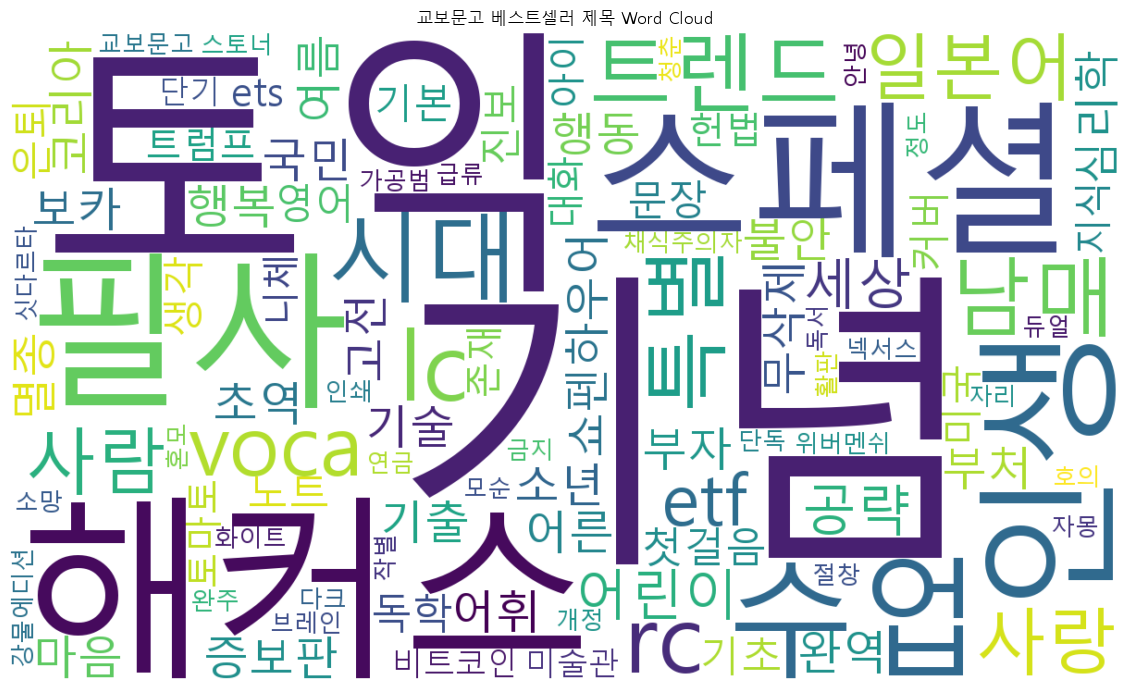

이미지 파일 생성 확인: True


In [88]:
from pathlib import Path
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# 단어 빈도로 Word Cloud 만들기
wordcloud = WordCloud(
    font_path=str(FONT_PATH),
    width=1200,
    height=700,
    background_color="white",
    max_words=100,
    random_state=42,
).generate_from_frequencies(final_counter)

# Notebook에 표시
plt.figure(figsize=(12, 7))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("교보문고 베스트셀러 제목 Word Cloud")
plt.tight_layout()
plt.show()

# 이미지 파일로 저장하고 확인
file_name = "chapter02_wordcloud.png"
wordcloud.to_file(file_name)
print("이미지 파일 생성 확인:", Path(file_name).exists())

### 실습 23. Word Cloud 해석하기

Word Cloud에서 글자가 클수록 이번에 분석한 도서 제목에 더 자주 나온 단어입니다.

이는 **제목의 단어 빈도**를 보여 주는 결과이며, 책이 많이 팔린 원인이나 독자의 선호도를 뜻하지는 않습니다.